# INFO-H512 Project

### Counterfactuals fairness 

*what is the accuracy cost of enforc-
ing counterfactual fairness, and does it provide measurable
equity gains over simpler observational baselines?*

Let's first import the libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)

Then we load the dataset 
- `LSAT`, `UGPA`, `ZFYA` — continuous features
- `race`, `sex` — protected attributes

In [3]:
df = pd.read_csv("../Data/law_data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (21791, 9)


,Unnamed: 0,race,sex,LSAT,UGPA,region_first,ZFYA,sander_index,first_pf
0,0,White,1,39.0,3.1,GL,-0.98,0.782738,1.0
1,1,White,1,36.0,3.0,GL,0.09,0.735714,1.0
2,2,White,2,30.0,3.1,MS,-0.35,0.670238,1.0
3,5,Hispanic,2,39.0,2.2,NE,0.58,0.697024,1.0
4,6,White,1,37.0,3.4,GL,-1.26,0.786310,1.0


## Preprocessing

We prepare the features for modeling:
- Recode `sex`: 1 (male) → 1, 2 (female) → 0
- One-hot encode `race`, using **White** as the reference category (most populated, default group in Kusner et al.)
- Drop unused columns (`region_first`, `sander_index`, `first_pf`, `Unnamed: 0`)


In [4]:
df["sex"] = (df["sex"] == 1).astype(int)

df = pd.get_dummies(df, columns=["race"], dtype=int)
df = df.drop(columns=["race_White"])

race_cols = [c for c in df.columns if c.startswith("race_")]
cols = ["LSAT", "UGPA", "ZFYA", "sex"] + race_cols
df = df[cols]

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape: (21791, 11)
Columns: ['LSAT', 'UGPA', 'ZFYA', 'sex', 'race_Amerindian', 'race_Asian', 'race_Black', 'race_Hispanic', 'race_Mexican', 'race_Other', 'race_Puertorican']


,LSAT,UGPA,ZFYA,sex,race_Amerindian,race_Asian,race_Black,race_Hispanic,race_Mexican,race_Other,race_Puertorican
0,39.0,3.1,-0.98,1,0,0,0,0,0,0,0
1,36.0,3.0,0.09,1,0,0,0,0,0,0,0
2,30.0,3.1,-0.35,0,0,0,0,0,0,0,0
3,39.0,2.2,0.58,0,0,0,0,1,0,0,0
4,37.0,3.4,-1.26,1,0,0,0,0,0,0,0


## Train/Test Split

80/20 split 

In [5]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {df_train.shape}, Test: {df_test.shape}")


Train: (17432, 11), Test: (4359, 11)


## Model 1 : Full

The "Full" baseline uses **all features** to predict ZFYA, including the protected 
attributes `race` and `sex`. This is the most accurate but **unfair** baseline 
(it explicitly uses race/sex in the decision).

Expected: lowest RMSE of all 4 models, but counterfactually unfair.


In [6]:
features_full = [c for c in df.columns if c != "ZFYA"]

model_full = LinearRegression()
model_full.fit(df_train[features_full], df_train["ZFYA"])
y_pred_full = model_full.predict(df_test[features_full])

rmse_full = np.sqrt(mean_squared_error(df_test["ZFYA"], y_pred_full))
print(f"Full RMSE: {rmse_full:.3f}")


Full RMSE: 0.881


## Model 2 : Unaware

"Fairness through unawareness": we **drop the protected attributes** (race, sex)
and predict ZFYA from `LSAT` and `UGPA` only.

This is a naive attempt at fairness: by not feeding race/sex into the model, we 
*hope* predictions become fair. But LSAT and UGPA are themselves biased (they are 
descendants of race/sex in the causal graph), so the bias leaks through anyway. 
This is the second **unfair baseline** in the paper.

Expected: RMSE slightly worse than Full (we removed informative features), 
but predictions still biased.


In [8]:
features_unaware = ["LSAT", "UGPA"]

model_unaware = LinearRegression()
model_unaware.fit(df_train[features_unaware], df_train["ZFYA"])
y_pred_unaware = model_unaware.predict(df_test[features_unaware])

rmse_unaware = np.sqrt(mean_squared_error(df_test["ZFYA"], y_pred_unaware))
print(f"Unaware RMSE: {rmse_unaware:.3f}")


Unaware RMSE: 0.907


## Model 3 : FairAdd (Level 3)

The first **counterfactually fair** model. Procedure (Kusner et al., page 9):

1. Regress `LSAT` on `(race, sex)` → get residuals `ε_LSAT` (the part of LSAT 
   NOT explained by protected attributes).
2. Same for `UGPA` → `ε_UGPA`.
3. Use `(ε_LSAT, ε_UGPA)` as fair features to predict `ZFYA`.

**Intuition:** residuals are by construction independent of `race` and `sex` 
(orthogonal to them after a linear regression), so any predictor built only on 
them inherits that fairness.

Expected: RMSE worse than Unaware (we removed more signal), counterfactually fair.


In [16]:
protected_cols = ["sex"] + race_cols

# Step 1: regress LSAT and UGPA on protected attributes
reg_lsat = LinearRegression().fit(df_train[protected_cols], df_train["LSAT"])
reg_ugpa = LinearRegression().fit(df_train[protected_cols], df_train["UGPA"])

# Step 2: compute residuals (train and test)
eps_lsat_train = df_train["LSAT"] - reg_lsat.predict(df_train[protected_cols])
eps_ugpa_train = df_train["UGPA"] - reg_ugpa.predict(df_train[protected_cols])
eps_lsat_test  = df_test["LSAT"]  - reg_lsat.predict(df_test[protected_cols])
eps_ugpa_test  = df_test["UGPA"]  - reg_ugpa.predict(df_test[protected_cols])

# Step 3: use residuals as fair features to predict ZFYA
X_fair_train = np.column_stack([eps_lsat_train, eps_ugpa_train])
X_fair_test  = np.column_stack([eps_lsat_test,  eps_ugpa_test])

model_fairadd = LinearRegression()
model_fairadd.fit(X_fair_train, df_train["ZFYA"])
y_pred_fairadd = model_fairadd.predict(X_fair_test)

rmse_fairadd = np.sqrt(mean_squared_error(df_test["ZFYA"], y_pred_fairadd))
print(f"FairAdd RMSE: {rmse_fairadd:.3f}")



FairAdd RMSE: 0.933


##  Model 4 : FairK (Level 2)

The Level 2 model treats Knowledge `K` as a latent variable inferred via MCMC.
Generative model (Kusner et al., page 8):

    K     ~ N(0, 1)
    UGPA  ~ N(b_G + w_K_G·K + w_R_G·race + w_S_G·sex, σ_G)
    LSAT  ~ Poisson(exp(b_L + w_K_L·K + w_R_L·race + w_S_L·sex))
    ZFYA  ~ N(w_K_F·K + w_R_F·race + w_S_F·sex, 1)

###  Setup PyMC + prepare data arrays

We use PyMC (Python equivalent of Stan) with the NUTS sampler. For inference, we
concatenate train and test sets so that K is sampled for every student in one MCMC
run. ZFYA is only observed for training rows.


In [17]:
import pymc as pm
print(f"PyMC version: {pm.__version__}")

# Concatenate train + test for joint inference of K
df_all = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
n_train = len(df_train)
n_total = len(df_all)

# Prepare numpy arrays
LSAT_all = df_all["LSAT"].values.astype(int)        # Poisson needs integers
UGPA_all = df_all["UGPA"].values
sex_all  = df_all["sex"].values
race_all = df_all[race_cols].values                  # shape (n_total, 7)
ZFYA_train = df_train["ZFYA"].values                 # ZFYA only for train

print(f"n_train: {n_train} | n_total: {n_total}")
print(f"LSAT shape: {LSAT_all.shape} | UGPA shape: {UGPA_all.shape}")
print(f"Race matrix shape: {race_all.shape}")


PyMC version: 6.0.0
n_train: 17432 | n_total: 21791
LSAT shape: (21791,) | UGPA shape: (21791,)
Race matrix shape: (21791, 7)


###  Build the Bayesian Model + Sample

We translate the generative equations into PyMC syntax. The model has:
- **~21k latent K variables** (one per student)
- **~25 regression weights** to be learned

⚠️ **Sampling is slow**: expect **10–30 min** depending on your machine. If too slow,
reduce `draws` to 300 and `tune` to 200, or subsample your data first.


In [19]:
with pm.Model() as fairk_model:
    # ---------- Latent variable: Knowledge ----------
    K = pm.Normal("K", mu=0, sigma=1, shape=n_total)
    
    # ---------- GPA equation params ----------
    b_G     = pm.Normal("b_G",   mu=0, sigma=10)
    w_K_G   = pm.Normal("w_K_G", mu=0, sigma=10)
    w_S_G   = pm.Normal("w_S_G", mu=0, sigma=10)
    w_R_G   = pm.Normal("w_R_G", mu=0, sigma=10, shape=race_all.shape[1])
    sigma_G = pm.HalfNormal("sigma_G", sigma=2)
    
    # ---------- LSAT equation params ----------
    b_L   = pm.Normal("b_L",   mu=0, sigma=10)
    w_K_L = pm.Normal("w_K_L", mu=0, sigma=10)
    w_S_L = pm.Normal("w_S_L", mu=0, sigma=10)
    w_R_L = pm.Normal("w_R_L", mu=0, sigma=10, shape=race_all.shape[1])
    
    # ---------- FYA equation params ----------
    w_K_F = pm.Normal("w_K_F", mu=0, sigma=10)
    w_S_F = pm.Normal("w_S_F", mu=0, sigma=10)
    w_R_F = pm.Normal("w_R_F", mu=0, sigma=10, shape=race_all.shape[1])
    
    # ---------- Likelihoods ----------
    # UGPA observed for ALL students
    mu_G = b_G + w_K_G * K + w_S_G * sex_all + pm.math.dot(race_all, w_R_G)
    pm.Normal("G_obs", mu=mu_G, sigma=sigma_G, observed=UGPA_all)
    
    # LSAT observed for ALL students (Poisson with log-link)
    mu_L = b_L + w_K_L * K + w_S_L * sex_all + pm.math.dot(race_all, w_R_L)
    pm.Poisson("L_obs", mu=pm.math.exp(mu_L), observed=LSAT_all)
    
    # ZFYA observed for TRAIN students only (first n_train rows)
    mu_F = (w_K_F * K[:n_train]
            + w_S_F * sex_all[:n_train]
            + pm.math.dot(race_all[:n_train], w_R_F))
    pm.Normal("F_obs", mu=mu_F, sigma=1.0, observed=ZFYA_train)
    
    # ---------- Sample ----------
    trace = pm.sample(draws=2000, tune=1000, chains=4, cores=4,
                      random_seed=42, target_accept=0.9)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [K, b_G, w_K_G, w_S_G, w_R_G, sigma_G, b_L, w_K_L, w_S_L, w_R_L, w_K_F, w_S_F, w_R_F]


/Users/pierrelechaude/miniconda3/envs/Business/lib/python3.13/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 280 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### Extract K + Fit Final Predictor + Compute RMSE

The MCMC produced posterior samples of `K` for every student. We:
1. Take the posterior **mean** of K for each student (point estimate).
2. Fit a simple linear regression `ZFYA = β₀ + β₁·K` on **train data only**.
3. Apply this predictor to test students (using their inferred K).

The final predictor is a **function of K alone** — race and sex don't appear in 
it, so it's counterfactually fair by Lemma 1 (Kusner et al., page 5).


In [20]:
# Posterior mean of K for each student
K_post_mean = trace.posterior["K"].mean(dim=["chain", "draw"]).values

# Split: first n_train rows = train; rest = test
K_train_mean = K_post_mean[:n_train]
K_test_mean  = K_post_mean[n_train:]

# Fit final predictor: ZFYA ~ K (only K → fair)
model_fairk = LinearRegression()
model_fairk.fit(K_train_mean.reshape(-1, 1), ZFYA_train)

# Predict on test
y_pred_fairk = model_fairk.predict(K_test_mean.reshape(-1, 1))

# RMSE
rmse_fairk = np.sqrt(mean_squared_error(df_test["ZFYA"], y_pred_fairk))
print(f"FairK RMSE: {rmse_fairk:.3f}")


FairK RMSE: 0.944


## Reproduction of Table 1 — RMSE Comparison

We reproduce Table 1 (Kusner et al., page 9): RMSE for all four models on the 
test set. Order follows the original paper (Full, Unaware, FairK, FairAdd).


In [21]:
results = pd.DataFrame({
    "Model":        ["Full", "Unaware", "FairK", "FairAdd"],
    "RMSE (ours)":  [rmse_full, rmse_unaware, rmse_fairk, rmse_fairadd],
    "RMSE (paper)": [0.873, 0.894, 0.929, 0.918],
})
results["Difference"] = (results["RMSE (ours)"] - results["RMSE (paper)"]).round(3)
print(results.to_string(index=False))


  Model  RMSE (ours)  RMSE (paper)  Difference
   Full     0.881046         0.873       0.008
Unaware     0.906713         0.894       0.013
  FairK     0.943736         0.929       0.015
FairAdd     0.933026         0.918       0.015


##  Reproduction of Figure 2: Density Plots by Group

For each model, we plot the density of predicted ZFYA broken down by protected 
attribute (race and sex). 

**Interpretation:** a counterfactually fair model produces *overlapping* densities
across groups — the predicted ZFYA distribution should not depend on the value
of a protected attribute. An unfair model produces shifted distributions.

We focus on the four main race categories (White, Black, Asian, Mexican) which 
account for ~95% of the dataset.

**Note:** Kusner et al. Figure 2 shows densities under original vs counterfactual
race for the *same* individuals. Our group-level comparison is a slightly weaker
but more transparent variant: if a model is fair, predictions should be marginally
invariant across group memberships.


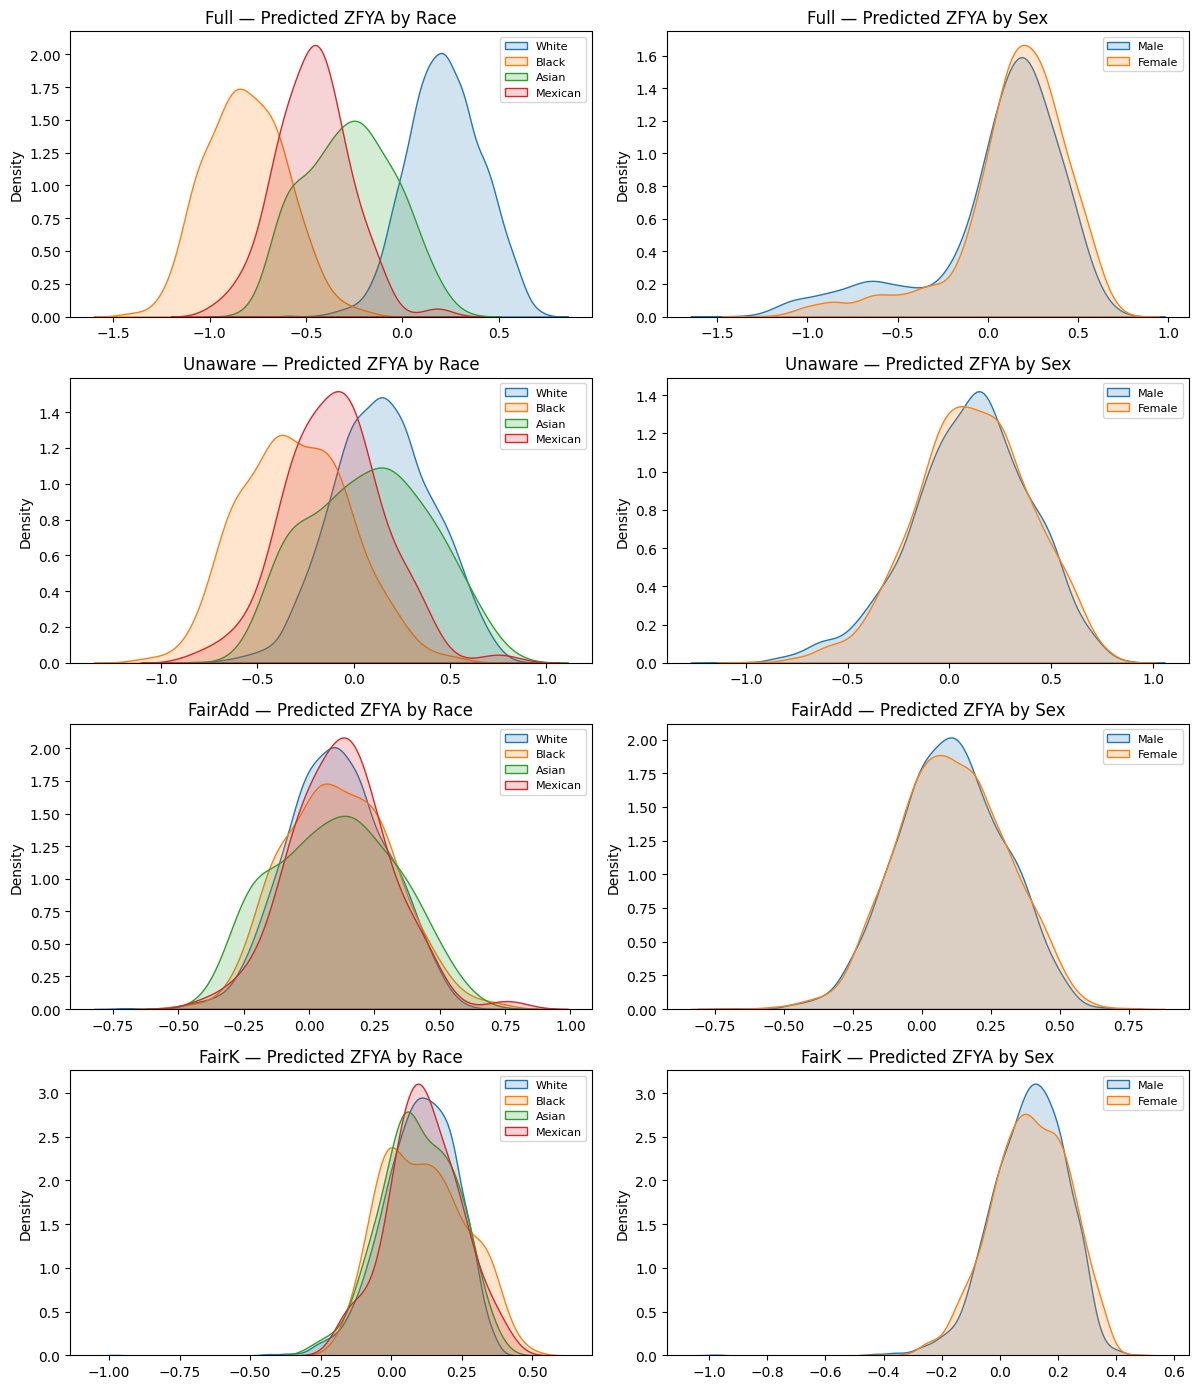

In [22]:
# Recover race string from one-hot encoding (for plotting)
race_names_no_white = [c.replace("race_", "") for c in race_cols]
race_array = df_test[race_cols].values
has_explicit_race = race_array.sum(axis=1) > 0
race_idx_arr = race_array.argmax(axis=1)
race_str = np.where(has_explicit_race, np.array(race_names_no_white)[race_idx_arr], "White")

# Build a single DataFrame with all predictions and protected attributes
plot_df = pd.DataFrame({
    "race": race_str,
    "sex":  df_test["sex"].values,
    "Full":    y_pred_full,
    "Unaware": y_pred_unaware,
    "FairAdd": y_pred_fairadd,
    "FairK":   y_pred_fairk,
})

# Restrict to main race categories
main_races = ["White", "Black", "Asian", "Mexican"]
plot_df_race = plot_df[plot_df["race"].isin(main_races)]

# 4 models × 2 protected attributes
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
models = ["Full", "Unaware", "FairAdd", "FairK"]

for i, model in enumerate(models):
    # Left column: density by race
    for race in main_races:
        subset = plot_df_race[plot_df_race["race"] == race]
        sns.kdeplot(subset[model], ax=axes[i, 0], label=race, fill=True, alpha=0.2)
    axes[i, 0].set_title(f"{model} — Predicted ZFYA by Race")
    axes[i, 0].set_xlabel("")
    axes[i, 0].legend(fontsize=8)
    
    # Right column: density by sex
    for sex_val, sex_lbl in [(1, "Male"), (0, "Female")]:
        subset = plot_df[plot_df["sex"] == sex_val]
        sns.kdeplot(subset[model], ax=axes[i, 1], label=sex_lbl, fill=True, alpha=0.2)
    axes[i, 1].set_title(f"{model} — Predicted ZFYA by Sex")
    axes[i, 1].set_xlabel("")
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()
